In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


In [3]:
df = pd.read_csv('../data/steam_games_clean.csv')
features = df[['avg_playtime_hours', 'main_genre']]


In [4]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), ['avg_playtime_hours']),
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['main_genre'])
])
X_processed = preprocessor.fit_transform(features)

In [6]:
import matplotlib.pyplot as plt

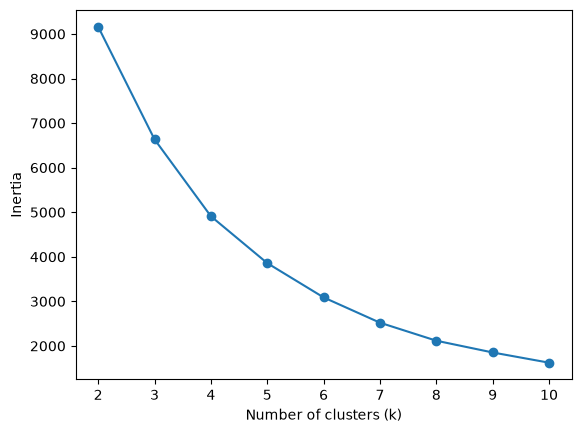

In [26]:
inertias = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_processed)
    inertias.append(km.inertia_)

plt.plot(range(2, 11), inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.savefig('../images/elbow_plot.png')
plt.show()


In [12]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_processed)
df.groupby('cluster')['main_genre'].value_counts().groupby(level=0).head(5)



cluster  main_genre
0        Action        4541
1        Action           3
         Sports           3
         Arcade           1
         RPG              1
2        Adventure     1456
3        Strategy       695
         RPG            525
         Simulation     271
         Casual         219
         Sports         156
4        Action          42
         RPG             18
         Sports          10
         Simulation       8
         Adventure        8
Name: count, dtype: int64

In [17]:
def recommend_similar_games(game_name, n=5):
    row = df[df['title'] == game_name]
    if row.empty:
        return f'"{game_name}" not found in dataset'
    cluster_id = row['cluster'].values[0]
    same_cluster = df[(df['cluster'] == cluster_id) & (df['title'] != game_name)]
    return same_cluster.sample(min(n, len(same_cluster)))[['title', 'main_genre', 'user_rating']]


In [25]:
recommend_similar_games('Apex Legends')  # try any game name from the dataset

,title,main_genre,user_rating
6286,Dynasty Warriors Next,Action,2.38
5709,Switchcars,Action,2.07
5720,Gloomwood,Action,4.00
1757,Worms Crazy Golf,Action,2.64
669,HELLDIVERS,Action,3.61
